In [1]:
import pandas as pd

In [2]:
df=pd.read_csv('Food_Delivery_Time_Prediction.csv')
df.head()

,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount
0,ORD0001,"(17.030479, 79.743077)","(12.358515, 85.100083)",1.57,Rainy,Medium,4,Medium,Afternoon,Car,4.1,3.0,26.22,1321.10,81.54
1,ORD0002,"(15.398319, 86.639122)","(14.174874, 77.025606)",21.32,Cloudy,Medium,8,Low,Night,Car,4.5,4.2,62.61,152.21,29.02
2,ORD0003,"(15.687342, 83.888808)","(19.594748, 82.048482)",6.95,Snowy,Medium,9,High,Night,Bike,3.3,3.4,48.43,1644.38,64.17
3,ORD0004,"(20.415599, 78.046984)","(16.915906, 78.278698)",13.79,Cloudy,Low,2,Medium,Evening,Bike,3.2,3.7,111.63,541.25,79.23
4,ORD0005,"(14.786904, 78.706532)","(15.206038, 86.203182)",6.72,Rainy,High,6,Low,Night,Bike,3.5,2.8,32.38,619.81,2.34


In [3]:
ordinal_features = ['Order_Priority', 'Traffic_Conditions']


ordinal_maps = {
    'Order_Priority': {'Low':0, 'Medium':1, 'High':2},
    'Traffic_Conditions': {'Low':0, 'Medium':1, 'High':2},
 #   'Order_Time':{'Afternoon':0,'Evening':2,'Night':1,'Morning':3},
 #   'Weather_Conditions':{'Sunny':0,'Cloudy':1,"Rainy":2,'Snowy'
}

for col in ordinal_features:
    df[col] = df[col].map(ordinal_maps[col])
df = pd.get_dummies(df, columns=['Vehicle_Type','Weather_Conditions','Order_Time'])

In [4]:
df.head()

,Order_ID,Customer_Location,Restaurant_Location,Distance,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Restaurant_Rating,Customer_Rating,Delivery_Time,...,Vehicle_Type_Bike,Vehicle_Type_Car,Weather_Conditions_Cloudy,Weather_Conditions_Rainy,Weather_Conditions_Snowy,Weather_Conditions_Sunny,Order_Time_Afternoon,Order_Time_Evening,Order_Time_Morning,Order_Time_Night
0,ORD0001,"(17.030479, 79.743077)","(12.358515, 85.100083)",1.57,1,4,1,4.1,3.0,26.22,...,False,True,False,True,False,False,True,False,False,False
1,ORD0002,"(15.398319, 86.639122)","(14.174874, 77.025606)",21.32,1,8,0,4.5,4.2,62.61,...,False,True,True,False,False,False,False,False,False,True
2,ORD0003,"(15.687342, 83.888808)","(19.594748, 82.048482)",6.95,1,9,2,3.3,3.4,48.43,...,True,False,False,False,True,False,False,False,False,True
3,ORD0004,"(20.415599, 78.046984)","(16.915906, 78.278698)",13.79,0,2,1,3.2,3.7,111.63,...,True,False,True,False,False,False,False,True,False,False
4,ORD0005,"(14.786904, 78.706532)","(15.206038, 86.203182)",6.72,2,6,0,3.5,2.8,32.38,...,True,False,False,True,False,False,False,False,False,True


In [5]:
import numpy as np

# split latitude and longitude
import numpy as np

# remove parentheses
df['Customer_Location'] = df['Customer_Location'].str.replace('(', '', regex=False).str.replace(')', '', regex=False)
df['Restaurant_Location'] = df['Restaurant_Location'].str.replace('(', '', regex=False).str.replace(')', '', regex=False)

# split latitude and longitude
df[['cust_lat','cust_lon']] = df['Customer_Location'].str.split(',', expand=True).astype(float)
df[['rest_lat','rest_lon']] = df['Restaurant_Location'].str.split(',', expand=True).astype(float)

# Haversine function using the :contentReference[oaicite:0]{index=0}
def haversine(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians,[lat1, lon1, lat2, lon2])
    
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    R = 6371
    return R * c

# calculate distance
df['Actual_Distance_km'] = haversine(
    df['cust_lat'],
    df['cust_lon'],
    df['rest_lat'],
    df['rest_lon']
)
df=df.drop(['Distance','cust_lat','cust_lon','rest_lat','rest_lon'],axis=1)
df.head()

,Order_ID,Customer_Location,Restaurant_Location,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,...,Vehicle_Type_Car,Weather_Conditions_Cloudy,Weather_Conditions_Rainy,Weather_Conditions_Snowy,Weather_Conditions_Sunny,Order_Time_Afternoon,Order_Time_Evening,Order_Time_Morning,Order_Time_Night,Actual_Distance_km
0,ORD0001,"17.030479, 79.743077","12.358515, 85.100083",1,4,1,4.1,3.0,26.22,1321.10,...,True,False,True,False,False,True,False,False,False,775.651198
1,ORD0002,"15.398319, 86.639122","14.174874, 77.025606",1,8,0,4.5,4.2,62.61,152.21,...,True,True,False,False,False,False,False,False,True,1042.385597
2,ORD0003,"15.687342, 83.888808","19.594748, 82.048482",1,9,2,3.3,3.4,48.43,1644.38,...,False,False,False,True,False,False,False,False,True,476.220706
3,ORD0004,"20.415599, 78.046984","16.915906, 78.278698",0,2,1,3.2,3.7,111.63,541.25,...,False,True,False,False,False,False,True,False,False,389.912629
4,ORD0005,"14.786904, 78.706532","15.206038, 86.203182",2,6,0,3.5,2.8,32.38,619.81,...,False,False,True,False,False,False,False,False,True,806.505886


In [6]:
from sklearn.preprocessing import MinMaxScaler
num_cols=['Delivery_Person_Experience',
          'Restaurant_Rating','Customer_Rating','Delivery_Time','Order_Cost','Actual_Distance_km']

scaler = MinMaxScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])
df[num_cols].head()
df.head()

,Order_ID,Customer_Location,Restaurant_Location,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,...,Vehicle_Type_Car,Weather_Conditions_Cloudy,Weather_Conditions_Rainy,Weather_Conditions_Snowy,Weather_Conditions_Sunny,Order_Time_Afternoon,Order_Time_Evening,Order_Time_Morning,Order_Time_Night,Actual_Distance_km
0,ORD0001,"17.030479, 79.743077","12.358515, 85.100083",1,0.333333,1,0.64,0.166667,0.105228,0.639319,...,True,False,True,False,False,True,False,False,False,0.587518
1,ORD0002,"15.398319, 86.639122","14.174874, 77.025606",1,0.777778,0,0.80,0.666667,0.453658,0.015951,...,True,True,False,False,False,False,False,False,True,0.797649
2,ORD0003,"15.687342, 83.888808","19.594748, 82.048482",1,0.888889,2,0.32,0.333333,0.317886,0.811724,...,False,False,False,True,False,False,False,False,True,0.351630
3,ORD0004,"20.415599, 78.046984","16.915906, 78.278698",0,0.111111,1,0.28,0.458333,0.923018,0.223426,...,False,True,False,False,False,False,True,False,False,0.283637
4,ORD0005,"14.786904, 78.706532","15.206038, 86.203182",2,0.555556,0,0.40,0.083333,0.164209,0.265322,...,False,False,True,False,False,False,False,False,True,0.611825


In [7]:
df_select=df.drop(['Order_Cost','Tip_Amount','Customer_Location','Restaurant_Location','Order_ID'],axis=1)
df_select.head()

,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Restaurant_Rating,Customer_Rating,Delivery_Time,Vehicle_Type_Bicycle,Vehicle_Type_Bike,Vehicle_Type_Car,Weather_Conditions_Cloudy,Weather_Conditions_Rainy,Weather_Conditions_Snowy,Weather_Conditions_Sunny,Order_Time_Afternoon,Order_Time_Evening,Order_Time_Morning,Order_Time_Night,Actual_Distance_km
0,1,0.333333,1,0.64,0.166667,0.105228,False,False,True,False,True,False,False,True,False,False,False,0.587518
1,1,0.777778,0,0.80,0.666667,0.453658,False,False,True,True,False,False,False,False,False,False,True,0.797649
2,1,0.888889,2,0.32,0.333333,0.317886,False,True,False,False,False,True,False,False,False,False,True,0.351630
3,0,0.111111,1,0.28,0.458333,0.923018,False,True,False,True,False,False,False,False,True,False,False,0.283637
4,2,0.555556,0,0.40,0.083333,0.164209,False,True,False,False,True,False,False,False,False,False,True,0.611825


In [8]:
avg_sp=df_select['Actual_Distance_km'].sum()/df_select['Delivery_Time'].sum()
df_select['exp_time']=df_select['Actual_Distance_km']/avg_sp
df_select['rush_score']=df_select['Delivery_Time']/df_select['exp_time']
#df.head()
mean=df_select['rush_score'].mean()
df_select['rush'] = df_select['rush_score'].apply(lambda x: 1 if x > mean else 0)
df_select=df_select.drop(['rush_score','exp_time'],axis=1)

In [9]:
threshold = df["Delivery_Time"].mean()
df_select["Delivery_Status"] = (df["Delivery_Time"] > threshold).astype(int)
df_select.head()

,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Restaurant_Rating,Customer_Rating,Delivery_Time,Vehicle_Type_Bicycle,Vehicle_Type_Bike,Vehicle_Type_Car,Weather_Conditions_Cloudy,Weather_Conditions_Rainy,Weather_Conditions_Snowy,Weather_Conditions_Sunny,Order_Time_Afternoon,Order_Time_Evening,Order_Time_Morning,Order_Time_Night,Actual_Distance_km,rush,Delivery_Status
0,1,0.333333,1,0.64,0.166667,0.105228,False,False,True,False,True,False,False,True,False,False,False,0.587518,0,0
1,1,0.777778,0,0.80,0.666667,0.453658,False,False,True,True,False,False,False,False,False,False,True,0.797649,0,0
2,1,0.888889,2,0.32,0.333333,0.317886,False,True,False,False,False,True,False,False,False,False,True,0.351630,0,0
3,0,0.111111,1,0.28,0.458333,0.923018,False,True,False,True,False,False,False,False,True,False,False,0.283637,0,1
4,2,0.555556,0,0.40,0.083333,0.164209,False,True,False,False,True,False,False,False,False,False,True,0.611825,0,0


In [10]:
df_select.head()

,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Restaurant_Rating,Customer_Rating,Delivery_Time,Vehicle_Type_Bicycle,Vehicle_Type_Bike,Vehicle_Type_Car,Weather_Conditions_Cloudy,Weather_Conditions_Rainy,Weather_Conditions_Snowy,Weather_Conditions_Sunny,Order_Time_Afternoon,Order_Time_Evening,Order_Time_Morning,Order_Time_Night,Actual_Distance_km,rush,Delivery_Status
0,1,0.333333,1,0.64,0.166667,0.105228,False,False,True,False,True,False,False,True,False,False,False,0.587518,0,0
1,1,0.777778,0,0.80,0.666667,0.453658,False,False,True,True,False,False,False,False,False,False,True,0.797649,0,0
2,1,0.888889,2,0.32,0.333333,0.317886,False,True,False,False,False,True,False,False,False,False,True,0.351630,0,0
3,0,0.111111,1,0.28,0.458333,0.923018,False,True,False,True,False,False,False,False,True,False,False,0.283637,0,1
4,2,0.555556,0,0.40,0.083333,0.164209,False,True,False,False,True,False,False,False,False,False,True,0.611825,0,0


In [11]:
X=df_select.drop(['Actual_Distance_km','rush','Delivery_Status'],axis=1)
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
X_pca=pca.fit_transform(X)

In [12]:
X.head()

,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Restaurant_Rating,Customer_Rating,Delivery_Time,Vehicle_Type_Bicycle,Vehicle_Type_Bike,Vehicle_Type_Car,Weather_Conditions_Cloudy,Weather_Conditions_Rainy,Weather_Conditions_Snowy,Weather_Conditions_Sunny,Order_Time_Afternoon,Order_Time_Evening,Order_Time_Morning,Order_Time_Night
0,1,0.333333,1,0.64,0.166667,0.105228,False,False,True,False,True,False,False,True,False,False,False
1,1,0.777778,0,0.80,0.666667,0.453658,False,False,True,True,False,False,False,False,False,False,True
2,1,0.888889,2,0.32,0.333333,0.317886,False,True,False,False,False,True,False,False,False,False,True
3,0,0.111111,1,0.28,0.458333,0.923018,False,True,False,True,False,False,False,False,True,False,False
4,2,0.555556,0,0.40,0.083333,0.164209,False,True,False,False,True,False,False,False,False,False,True


In [16]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import *

C:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Wi

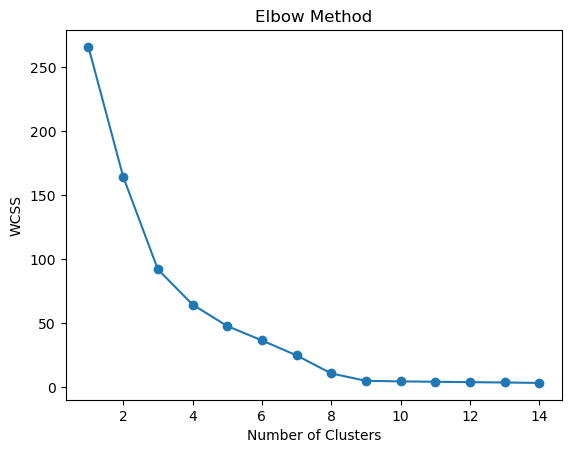

In [27]:
wcss = []
#max_k=0
for i in range(1, 15):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_pca)
    wcss.append(kmeans.inertia_)
   # print('accuracy for k=',i,accuracy_score(X_pca,kmeans.labels_))
   # max_k=max(i,max_k)
#print('optimal k is
plt.plot(range(1, 15), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()


In [28]:
for i in range(2,15):
    kmeans=KMeans(n_clusters=i,random_state=42)
    k_labels=kmeans.fit_predict(X_pca)
    score=silhouette_score(X_pca,kmeans.labels_)
    print('silhouette for k',i,'=',score)
    

C:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Wi

silhouette for k 2 = 0.3803056091767029
silhouette for k 3 = 0.4620148885587879
silhouette for k 4 = 0.46588952410166784
silhouette for k 5 = 0.5283283332789247
silhouette for k 6 = 0.5701010451005566
silhouette for k 7 = 0.6254056553057616
silhouette for k 8 = 0.7362157038872962
silhouette for k 9 = 0.7828840118456134
silhouette for k 10 = 0.7530599301587599
silhouette for k 11 = 0.7057930851560585
silhouette for k 12 = 0.6625844415600368
silhouette for k 13 = 0.6553795086096486
silhouette for k 14 = 0.6422418425268512


C:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


therefore for k=9,we can get high silhouette score (also verified by elbow method as shown in above graph,we can observe the curve is flattened after k=9)

In [29]:
from sklearn.cluster import KMeans
kmeans=KMeans(n_clusters=9,random_state=42)

k_labels=kmeans.fit_predict(X_pca)

from sklearn.metrics import silhouette_score

score = silhouette_score(X_pca, kmeans.labels_)
print("Silhouette Score:", score)
from sklearn.metrics import davies_bouldin_score,calinski_harabasz_score as chs

db_score = davies_bouldin_score(X_pca, kmeans.labels_)
print("Davies-Bouldin Index:", db_score)
print('calinski harabasz score:',chs(X_pca,kmeans.labels_))

Silhouette Score: 0.7828840118456134
Davies-Bouldin Index: 0.2996341839849598
calinski harabasz score: 1293.4418850600987


C:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


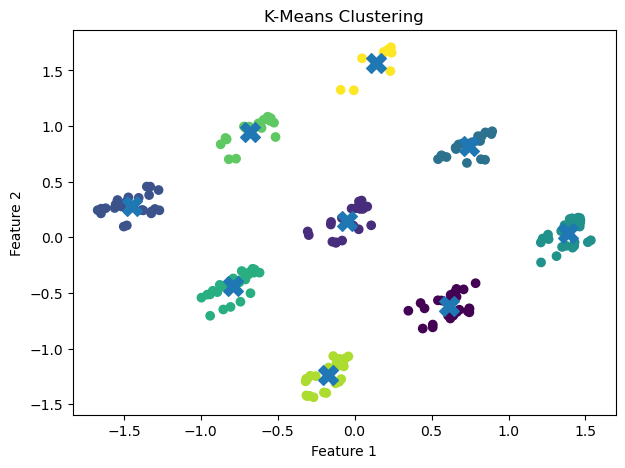

In [30]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7,5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=k_labels, cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            marker='X', s=200)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("K-Means Clustering")
plt.show()

In [31]:
from sklearn.cluster import AgglomerativeClustering

# Apply model
hc = AgglomerativeClustering(n_clusters=9, linkage='ward')

# Fit and predict
df['HC_Cluster'] = hc.fit_predict(X_pca)

In [33]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

for k in range(2, 15):
    model = AgglomerativeClustering(n_clusters=k)
    labels = model.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    print(f"k={k}, Silhouette={score}")

k=2, Silhouette=0.3833770388042658
k=3, Silhouette=0.4177115669072212
k=4, Silhouette=0.47167046368620946
k=5, Silhouette=0.5289198336895707
k=6, Silhouette=0.5931034374433185
k=7, Silhouette=0.6601863209428283
k=8, Silhouette=0.7365825452219813
k=9, Silhouette=0.7828840118456134
k=10, Silhouette=0.7530599301587599
k=11, Silhouette=0.7150690281368085
k=12, Silhouette=0.692888891674847
k=13, Silhouette=0.6735843212744302
k=14, Silhouette=0.6417095327792444


therefore,k=9 is optimal value based on above scores

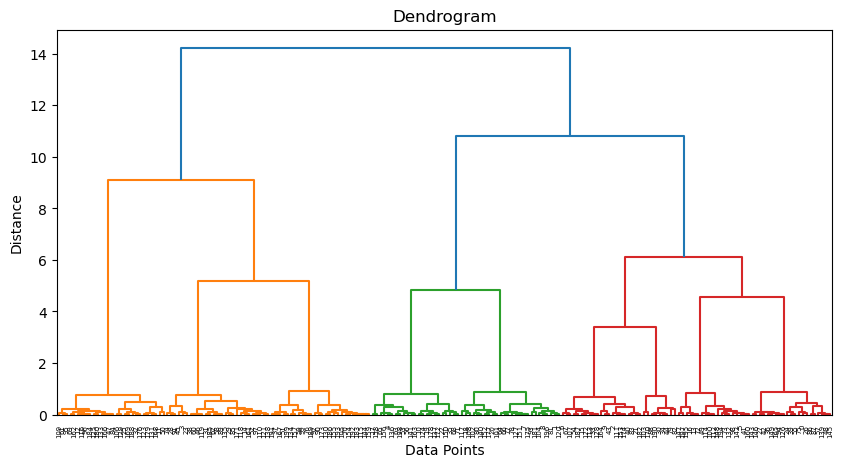

In [35]:
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

dendrogram = sch.dendrogram(sch.linkage(X_pca, method='ward'))

plt.title("Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

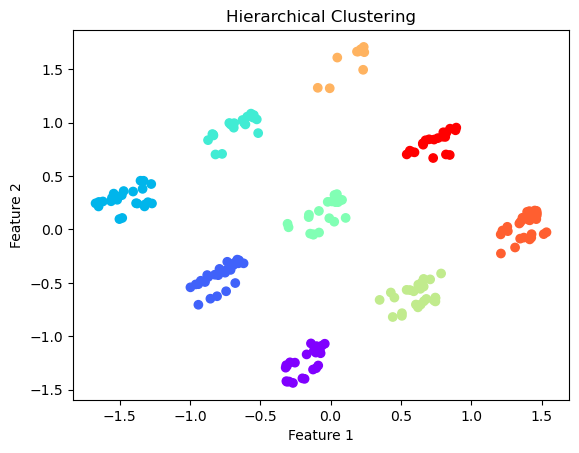

In [36]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['HC_Cluster'], cmap='rainbow')

plt.title("Hierarchical Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [37]:
df.groupby('HC_Cluster')['Delivery_Time'].mean()

HC_Cluster
0    0.597833
1    0.519842
2    0.477457
3    0.499123
4    0.582189
5    0.491312
6    0.565822
7    0.541548
8    0.502831
Name: Delivery_Time, dtype: float64

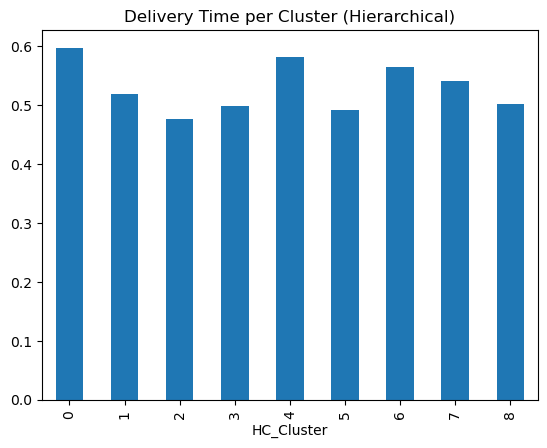

In [38]:
df.groupby('HC_Cluster')['Delivery_Time'].mean().plot(kind='bar')
plt.title("Delivery Time per Cluster (Hierarchical)")
plt.show()

In [39]:
df['Cluster']=k_labels

In [40]:
df[['Cluster', 'HC_Cluster']].head()

,Cluster,HC_Cluster
0,1,4
1,5,1
2,3,8
3,0,5
4,2,2


In [41]:
print("KMeans:\n", df.groupby('Cluster')['Delivery_Time'].mean())
print("\nHierarchical:\n", df.groupby('HC_Cluster')['Delivery_Time'].mean())

KMeans:
 Cluster
0    0.491312
1    0.582189
2    0.477457
3    0.502831
4    0.541548
5    0.519842
6    0.499123
7    0.597833
8    0.565822
Name: Delivery_Time, dtype: float64

Hierarchical:
 HC_Cluster
0    0.597833
1    0.519842
2    0.477457
3    0.499123
4    0.582189
5    0.491312
6    0.565822
7    0.541548
8    0.502831
Name: Delivery_Time, dtype: float64


In [42]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

sil = silhouette_score(X_pca, df['HC_Cluster'])
db = davies_bouldin_score(X_pca, df['HC_Cluster'])

print("Silhouette for HC:", sil)
print("DB Index for HC:", db)

Silhouette for HC: 0.7828840118456134
DB Index for HC: 0.2996341839849598


In [43]:
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split

In [44]:
X.head()

,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Restaurant_Rating,Customer_Rating,Delivery_Time,Vehicle_Type_Bicycle,Vehicle_Type_Bike,Vehicle_Type_Car,Weather_Conditions_Cloudy,Weather_Conditions_Rainy,Weather_Conditions_Snowy,Weather_Conditions_Sunny,Order_Time_Afternoon,Order_Time_Evening,Order_Time_Morning,Order_Time_Night
0,1,0.333333,1,0.64,0.166667,0.105228,False,False,True,False,True,False,False,True,False,False,False
1,1,0.777778,0,0.80,0.666667,0.453658,False,False,True,True,False,False,False,False,False,False,True
2,1,0.888889,2,0.32,0.333333,0.317886,False,True,False,False,False,True,False,False,False,False,True
3,0,0.111111,1,0.28,0.458333,0.923018,False,True,False,True,False,False,False,False,True,False,False
4,2,0.555556,0,0.40,0.083333,0.164209,False,True,False,False,True,False,False,False,False,False,True


In [45]:
y=df_select['Delivery_Status']

In [46]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,random_state=42)

In [47]:
model = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

# 7. Compile model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 8. Train model
model.fit(X_train, y_train, epochs=20)

# 9. Evaluate
model.evaluate(X_test, y_test)

C:\Users\LENOVO\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.4857 - loss: 0.7083
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6357 - loss: 0.6692
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6071 - loss: 0.6643
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7214 - loss: 0.6534
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7429 - loss: 0.6387
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7214 - loss: 0.6348
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7286 - loss: 0.6155
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7357 - loss: 0.6206
Epoch 9/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8214 - loss: 0.5834
Epoch 10/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7857 - loss: 0.5814
Epoch 11/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8071 - loss: 0.5486
Epoch 12/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7929 - loss: 0.5269
E

[0.4738828241825104, 0.75]

In [49]:
from sklearn.metrics import confusion_matrix,accuracy_score

y_pred = (model.predict(X_test) > 0.5).astype(int)
print('confusion matrix:',confusion_matrix(y_test, y_pred))
print('accuracy:',accuracy_score(y_test,y_pred))
print('precision:',precision_score(y_test,y_pred))
print('f1 score:',f1_score(y_test,y_pred))
print('recall:',recall_score(y_test,y_pred))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
confusion matrix: [[18  9]
 [ 6 27]]
accuracy: 0.75
precision: 0.75
f1 score: 0.782608695652174
recall: 0.8181818181818182
